# RNA viral diversity and community composition
## Alpha diversity across infaunal treatments; PCoA and PERMANOVA

In [ ]:

PROJ <- "./"
if (!dir.exists(PROJ)) PROJ <- "."
PROJ <- normalizePath(PROJ, mustWork = TRUE)

knitr::opts_knit$set(root.dir = PROJ)   # applies when knitting
setwd(PROJ)                             # applies when running chunks interactively

dir.create(file.path(PROJ, "outputs", "figures"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(PROJ, "outputs", "tables"),  recursive = TRUE, showWarnings = FALSE)

knitr::opts_chunk$set(echo = TRUE, message = FALSE, warning = FALSE,
                      fig.path = "outputs/figures/", dpi = 300)

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 109 taxa and 31 samples ]
sample_data() Sample Data:       [ 31 samples by 2 sample variables ]
tax_table()   Taxonomy Table:    [ 109 taxa by 5 taxonomic ranks ]

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have alrea

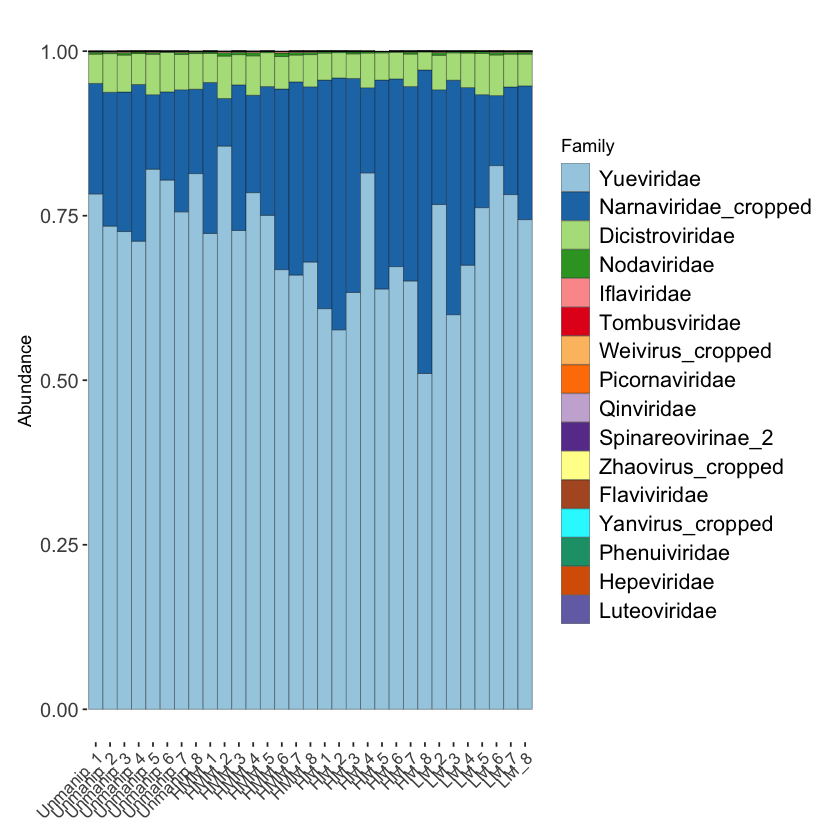

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have alrea

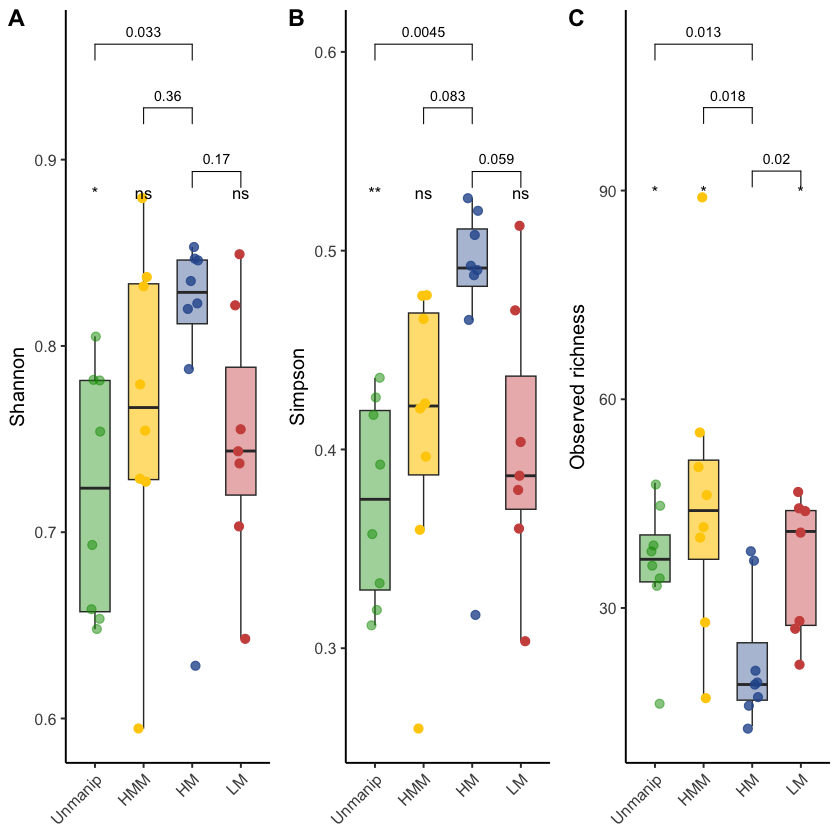

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Condition,3,0.09481721,0.3718344,5.327433,0.005
Residual,27,0.16018126,0.6281656,NA,NA
Total,30,0.25499847,1.0000000,NA,NA


R version 4.1.1 (2021-08-10)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS 26.4.1

Matrix products: default
BLAS/LAPACK: /Users/au657143/mambaforge/envs/maaslin/lib/libopenblasp-r0.3.23.dylib

locale:
[1] en_AU/en_AU/en_AU/C/en_AU/en_AU

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] microViz_0.12.1 dplyr_1.1.4     ggpubr_0.6.0    ggplot2_3.5.2  
[5] vegan_2.6-4     lattice_0.21-8  permute_0.9-7   phyloseq_1.38.0

loaded via a namespace (and not attached):
 [1] Biobase_2.54.0         tidyr_1.3.1            jsonlite_2.0.0        
 [4] splines_4.1.1          foreach_1.5.2          carData_3.0-5         
 [7] stats4_4.1.1           GenomeInfoDbData_1.2.7 backports_1.4.1       
[10] pillar_1.10.2          glue_1.8.0             uuid_1.2-0            
[13] digest_0.6.37          RColorBrewer_1.1-3     XVector_0.34.0        
[16] ggsignif_0.6.4         colorspace_2.1-0       cowplot_1.1.3    

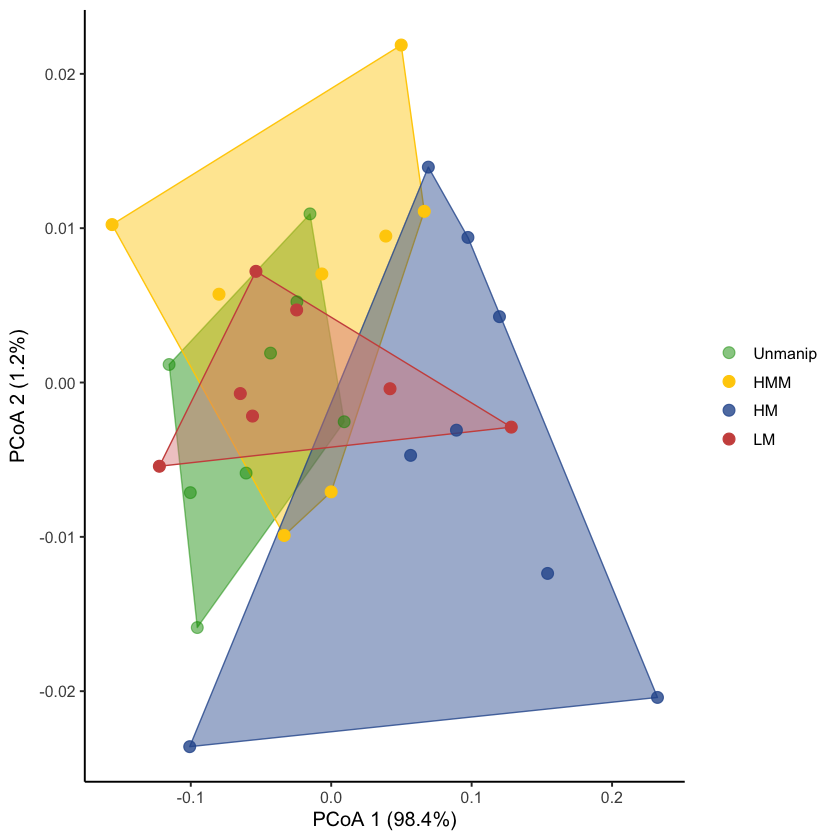

In [7]:
# R libraries
library(phyloseq)   # object model, ordination, richness
library(vegan)      # vegdist, adonis2
library(ggplot2)    # all plotting
library(ggpubr)     # significance brackets, panel assembly
library(dplyr)
library(microViz)

## Figure style

LEVELS <- c("Unmanip", "HMM", "HM", "LM")

COL_POINT <- c(Unmanip = "#00970080",   # points, dots
               HMM  = "#ffce04ff",
               HM   = "#2a579bcb",
               LM   = "#cd534cff")

COL_FILL  <- c(Unmanip = "#00970066",   # box fills, ordination hulls
               HMM  = "#ffcc0099",
               HM   = "#2a579b66",
               LM   = "#de87879a")

OUTLINE <- "grey20"

save_fig <- function(plot, name, width, height) {
  ggsave(file.path("outputs", "figures", paste0(name, ".pdf")),
         plot, width = width, height = height)
  if (requireNamespace("svglite", quietly = TRUE))
    ggsave(file.path("outputs", "figures", paste0(name, ".svg")),
           plot, width = width, height = height)
  invisible(plot)
}

## Build the phyloseq object

otus <- read.table("data/RNA_Viruses109.txt", header = TRUE, sep = "\t")
rownames(otus) <- otus$Genome
otu_mat <- as.matrix(otus[, -1])            # all columns except the genome ID

tax <- read.table("data/Taxonomy_109_RNA_virus.txt", header = TRUE, sep = "\t")
rownames(tax) <- tax$contigName
tax_mat <- as.matrix(tax[, 2:6])            

sampledata <- read.table("data/env_samples.txt", header = TRUE, sep = "\t")
rownames(sampledata) <- sampledata$Samples

# 1. Set Condition as an ordered factor
sampledata$Condition <- factor(sampledata$Condition, levels = LEVELS)

# 2. Re-order sampledata rows explicitly by Condition
sampledata <- sampledata[order(sampledata$Condition), ]

# 3. Re-align otu_mat columns to match the newly ordered sampledata rows
otu_mat <- otu_mat[, rownames(sampledata)]

# 4. Build phyloseq object
physeq <- phyloseq(otu_table(otu_mat, taxa_are_rows = TRUE),
                   tax_table(tax_mat),
                   sample_data(sampledata))

# 5. Drop genomes absent from every sample
virus.prune <- prune_taxa(taxa_sums(physeq) > 0, physeq)

# 6. Apply microViz ps_mutate and ps_arrange to ensure internal slots stay ordered
virus.prune <- virus.prune %>%
  ps_mutate(Condition = factor(Condition, levels = LEVELS)) %>%
  ps_arrange(Condition)

virus.prune

#### Distribution and abundance of RNA viral community ####
## RNA virus abundance - Barplot

plot.RNA.virus <- physeq %>%  tax_fix() %>% 
  comp_barplot("Family", n_taxa = 18, sample_order = "asis",
    bar_outline_colour = "black",                
  )  %>%
  patchwork::wrap_plots(nrow = 1, guides = "collect") & 

theme(axis.text.x = element_text(angle = 45, hjust = 1), axis.ticks.x = element_line())  & 
  theme(
    axis.text.y = element_text(size = 12),
    axis.text.x = element_text(size = 10),
    legend.text = element_text(size = 13),
    legend.position = "right" 
  )

plot.RNA.virus 

#### Alpha diversity ####

TEST <- "t.test"          
div_data <- function(measure) {
  d <- plot_richness(virus.prune, measures = measure)$data
  d$Condition <- factor(d$Condition, levels = LEVELS)
  d
}

comparisons <- list(c("HM", "LM"), c("HM", "HMM"), c("HM", "Unmanip"))

div_panel <- function(measure, ylab) {
  ggplot(div_data(measure), aes(Condition, value)) +
    geom_boxplot(aes(fill = Condition), colour = OUTLINE,
                 linewidth = 0.4, outlier.shape = NA, width = 0.62) +
    geom_point(aes(colour = Condition), size = 2.2,
               position = position_jitter(width = 0.12, seed = 1)) +
    scale_fill_manual(values = COL_FILL,  drop = FALSE) +
    scale_colour_manual(values = COL_POINT, drop = FALSE) +
    stat_compare_means(comparisons = comparisons, method = TEST, size = 3) +
    stat_compare_means(aes(label = after_stat(p.signif)),
                       method = TEST, ref.group = "HM", size = 3.5) +
    labs(x = NULL, y = ylab) +
    theme_classic(base_size = 12) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "none")
}

p_shannon <- div_panel("Shannon",  "Shannon")
p_simpson <- div_panel("Simpson",  "Simpson")
p_obs     <- div_panel("Observed", "Observed richness")


#Pairwise comparisons are made against LM only, the low-meiofauna end of the gradient.

fig_1c <- ggarrange(p_shannon, p_simpson, p_obs,
                    labels = c("A", "B", "C"),
                    ncol = 3, nrow = 1, align = "v")

save_fig(fig_1c, "Fig_1C_RNA_viral_diversity", width = 10, height = 4)
fig_1c


# Export the underlying values for Supplementary Table 2:

bind_rows(
  transform(div_data("Shannon"),  index = "Shannon"),
  transform(div_data("Simpson"),  index = "Simpson"),
  transform(div_data("Observed"), index = "Observed")
) %>%
  select(Sample = samples, Condition, index, value) %>%
  write.csv("outputs/tables/01_alpha_diversity.csv", row.names = FALSE)


## Community composition

### Relative abundance

#Converted to percentages per sample. Bray–Curtis is insensitive to this rescaling.

phy.norm  <- transform_sample_counts(virus.prune, function(x) x / sum(x) * 100)
otu_reads <- otu_table(t(phy.norm), taxa_are_rows = FALSE)   # samples in rows


### PCoA

#PCoA (metric multidimensional scaling) places samples in a low-dimensional space that preserves
#their pairwise dissimilarities. Unlike PCA it accepts any dissimilarity index, which is what
#allows Bray–Curtis to be used here.

#Axis labels report the proportion of variation each axis represents.'''

bray_dist <- vegan::vegdist(otu_reads, method = "bray")
ord       <- ordinate(phy.norm, "PCoA", distance = bray_dist)

pct <- round(100 * ord$values$Relative_eig[1:2], 1)

ord_df <- plot_ordination(phy.norm, ord, color = "Condition", justDF = TRUE)
ord_df$Condition <- factor(ord_df$Condition, levels = LEVELS)

hulls <- ord_df %>%
  group_by(Condition) %>%
  slice(chull(Axis.1, Axis.2)) %>%
  ungroup()

fig_1e <- ggplot(ord_df, aes(Axis.1, Axis.2)) +
  geom_polygon(data = hulls, aes(fill = Condition, colour = Condition),
               alpha = 0.45, linewidth = 0.4, show.legend = FALSE) +
  geom_point(aes(colour = Condition), size = 3) +
  scale_fill_manual(values = COL_FILL,  drop = FALSE) +
  scale_colour_manual(values = COL_POINT, drop = FALSE) +
  labs(x = paste0("PCoA 1 (", pct[1], "%)"),
       y = paste0("PCoA 2 (", pct[2], "%)"),
       colour = NULL) +
  theme_classic(base_size = 12) +
  theme(legend.position = "right")

save_fig(fig_1e, "Fig_1E_RNA_viral_PCoA", width = 5.5, height = 4.5)
fig_1e


### PERMANOVA

# Tests whether treatment explains the dissimilarity structure. The distance matrix and the
# metadata are aligned explicitly by sample name — `adonis2()` matches rows positionally.

meta <- as(sample_data(phy.norm), "data.frame")[attr(bray_dist, "Labels"), , drop = FALSE]
stopifnot(identical(rownames(meta), attr(bray_dist, "Labels")))

set.seed(1)
pm <- adonis2(bray_dist ~ Condition, data = meta, permutations = 9999)
pm

write.csv(as.data.frame(pm), "outputs/tables/01_permanova_condition.csv")


#The R² is the proportion of variation in viral community composition attributable to the
#infaunal treatments, and is the value quoted in the Results.

sessionInfo()
